In [2]:
!pip -q install -U datasets transformers accelerate scikit-learn iterative-stratification psutil

print("Installation complete.")

from collections import Counter

from google.colab import drive
drive.mount('/content/drive')

# Load the dataset WITHOUT downloading it again
from datasets import load_from_disk

dataset = load_from_disk(
    "/content/drive/MyDrive/multieurlex_all_languages"
)

# Get the label feature from the training split
label_feature = dataset["train"].features["labels"].feature

# Count every label occurrence across all splits
for split in dataset:
    label_counts = Counter()

    for labels in dataset[split]["labels"]:
        label_counts.update(labels)

    print(f"\n{split.upper()}")
    print("Documents:", dataset[split].num_rows)
    print("Unique labels used:", len(label_counts))
    print("Total label assignments:", sum(label_counts.values()))

# Number of possible EUROVOC label classes
print("\nTotal possible label classes:", len(label_feature.names))


Installation complete.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

TRAIN
Documents: 55000
Unique labels used: 500
Total label assignments: 312244

TEST
Documents: 5000
Unique labels used: 465
Total label assignments: 32784

VALIDATION
Documents: 5000
Unique labels used: 454
Total label assignments: 31705

Total possible label classes: 567


In [3]:
import json
import pandas as pd # Needed for displaying Series later
import numpy as np # Needed for np.nan

baseline_metrics = {}
try:
    with open('/content/drive/MyDrive/baseline_metrics.json', 'r') as f:
        loaded_metrics = json.load(f)
        baseline_metrics.update(loaded_metrics) # Update the dict
    print("Baseline metrics loaded from '/content/drive/MyDrive/baseline_metrics.json'.")
except FileNotFoundError:
    print("baseline_metrics.json not found in Google Drive. Initializing empty metrics.")

# Ensure 'baseline_train_time' is present, even if as NaN
if 'baseline_train_time' not in baseline_metrics:
    baseline_metrics['baseline_train_time'] = np.nan
    print("Added 'baseline_train_time' as NaN to baseline_metrics.")

if baseline_metrics: # Only display if there's content
    print("Baseline Metrics:")
    display(pd.Series(baseline_metrics).round(4))

baseline_metrics.json not found in Google Drive. Initializing empty metrics.
Added 'baseline_train_time' as NaN to baseline_metrics.
Baseline Metrics:


,0
baseline_train_time,NaN


In [4]:
# @title
import os
import time
import random
import numpy as np
import pandas as pd
import torch
import json

from accelerate import Accelerator # Import Accelerator

# Initialize Accelerator for mixed precision and device management
# 'bf16' is suitable for TPUs/newer GPUs
accelerator = Accelerator(mixed_precision='no')
#f32


# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ---- Main experiment controls ----
MAX_LENGTH = 256
BATCH_SIZE = 16
NUM_EPOCHS = 10
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
THRESHOLD = 0.50
N_TRAIN_PARTS = 10 # Number of chunks to divide the training data into

# Choose one:
#MODEL_NAME = "bert-base-multilingual-cased"   # mBERT
MODEL_NAME = "xlm-roberta-base"              # XLM-R

print("Model:", MODEL_NAME)

# Define checkpoint path
CHECKPOINT_PATH = "/content/drive/MyDrive/XLM-R_WEIGHT_checkpoint.pt"
TEMP_CHECKPOINT_PATH = "/content/drive/MyDrive/XLM-R_WEIGHT_checkpoint_tmp.pt"

# Initialize variables for checkpointing
start_epoch = 0
best_val_f1 = -np.inf
history = []

# Determine total training samples
total_training_samples = len(dataset["train"])

# Calculate total training steps and warmup steps
total_steps = (total_training_samples // BATCH_SIZE) * NUM_EPOCHS
warmup_steps = int(0.1 * total_steps)

print(f"Total training samples: {total_training_samples}")
print(f"Total training steps: {total_steps}")
print(f"Warmup steps: {warmup_steps}")

# # Load checkpoint if it exists

if os.path.exists(CHECKPOINT_PATH):
    print(f"\nCheckpoint found at {CHECKPOINT_PATH}. Loading state...")
    try:
        checkpoint = torch.load(CHECKPOINT_PATH, map_location='cpu')

        start_epoch = checkpoint["epoch"]
        best_val_f1 = checkpoint["best_val_f1"]
        history = checkpoint["history"]

        # Model, optimizer, scheduler states are loaded later after they are initialized
        print(f"Resuming training from Epoch {start_epoch + 1}.")
    except Exception as e:
        print(f"Error loading checkpoint: {e}. Starting fresh.")
        # Reset to default if checkpoint is corrupted or unreadable
        start_epoch = 0
        best_val_f1 = -np.inf
        history = []
else:
    print("\nNo checkpoint found. Starting training from Epoch 1.")

Model: xlm-roberta-base
Total training samples: 55000
Total training steps: 34370
Warmup steps: 3437

Checkpoint found at /content/drive/MyDrive/XLM-R_WEIGHT_checkpoint.pt. Loading state...
Resuming training from Epoch 10.


In [5]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

def multilabel_metrics(y_true, y_pred):
    return {
        "micro_f1": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "micro_precision": precision_score(y_true, y_pred, average="micro", zero_division=0),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "micro_recall": recall_score(y_true, y_pred, average="micro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "exact_match": accuracy_score(y_true, y_pred)
    }

In [6]:
TEXT_COLUMN = "text"
LABEL_COLUMN = "labels"

In [7]:
# Build a consistent label vocabulary directly from the dataset's label feature.
# This assumes `label_feature` is already defined (e.g., from cell `l578f8uhvqEu`).

# Get the list of all possible label names (EUROVOC IDs as strings)
all_label_names_from_dataset = label_feature.names
NUM_LABELS = len(all_label_names_from_dataset)

# Create a simple 0-based index mapping for the multi-hot vector
# where the key is the label's integer ID from the dataset, and value is its index in our vector
label_to_index = {i: i for i in range(NUM_LABELS)}

print("Number of labels:", NUM_LABELS)
print("First mappings (dataset label ID -> internal vector index):", list(label_to_index.items())[:10])

# --- Compute pos_weight for imbalanced multi-label BCE loss ---
# With a very low positive rate per label, unweighted BCE lets the model
# minimize loss by predicting "no label" everywhere. pos_weight rebalances
# the loss per-label so missing a rare positive costs proportionally more.
from collections import Counter

_label_pos_counts = Counter()
_total_docs = 0
for _labels_row in dataset["train"]["labels"]:
    _label_pos_counts.update(int(l) for l in _labels_row if int(l) in label_to_index)
    _total_docs += 1

pos_counts = np.array(
    [_label_pos_counts.get(i, 0) for i in range(NUM_LABELS)],
    dtype=np.float64
)
neg_counts = _total_docs - pos_counts
# Avoid divide-by-zero for labels that never appear in train; cap the ratio
# so a single-occurrence label doesn't produce an extreme, destabilizing weight.
pos_weight = np.clip(neg_counts / np.maximum(pos_counts, 1), a_min=1.0, a_max=50.0)
pos_weight_tensor = torch.tensor(pos_weight, dtype=torch.float32)
print(f"pos_weight range: min={pos_weight.min():.2f}, max={pos_weight.max():.2f}, mean={pos_weight.mean():.2f}")


Number of labels: 567
First mappings (dataset label ID -> internal vector index): [(0, 0), (1, 1), (2, 2), (3, 3), (4, 4), (5, 5), (6, 6), (7, 7), (8, 8), (9, 9)]
pos_weight range: min=3.27, max=50.00, mean=46.94


In [8]:
def multi_hot(label_ids, mapping):
    vector = np.zeros(len(mapping), dtype=np.float32)
    for label_id in label_ids:
        vector[mapping[int(label_id)]] = 1.0
    return vector

In [9]:
from functools import partial
from transformers import AutoTokenizer # Ensure tokenizer is available
from datasets import concatenate_datasets

# Re-initialize tokenizer if it was deleted or for freshness
# This ensures `tokenizer` is available for `preprocess_function`.
# Assuming MODEL_NAME is defined from an earlier cell.
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Function to apply tokenization and multi-hot encoding
def preprocess_function(examples, tokenizer, label_to_index, max_length):
    # Extract English text from the dictionary for tokenization
    texts_to_tokenize = [example.get('en', '') for example in examples[TEXT_COLUMN]]

    # Tokenize the text
    tokenized_inputs = tokenizer(
        texts_to_tokenize,
        truncation=True,
        max_length=max_length,
        padding=False # Do not pad here, pad dynamically in DataLoader
    )

    # Convert labels to multi-hot vectors
    multi_hot_labels = [
        multi_hot(
            [lbl for lbl in row if int(lbl) in label_to_index], # Filter labels not in label_to_index
            label_to_index
        )
        for row in examples[LABEL_COLUMN]
    ]
    tokenized_inputs["labels"] = multi_hot_labels
    return tokenized_inputs

# Prepare the partial function for mapping
preprocess_map_fn = partial(preprocess_function, tokenizer=tokenizer, label_to_index=label_to_index, max_length=MAX_LENGTH)

# --- Define training data chunking parameters ---
# N_TRAIN_PARTS is defined in VQsJZGmTjRTv and is globally available
train_split_size = len(dataset["train"])
part_size = train_split_size // N_TRAIN_PARTS

print(f"\nTraining data will be processed in {N_TRAIN_PARTS} parts (approx {part_size} examples each).")
print(f"Total training samples for original dataset: {train_split_size}")

# --- Process validation data ---
print("\nProcessing validation data...")
tokenized_val = dataset["validation"].map(
    preprocess_map_fn,
    batched=True,
    remove_columns=[TEXT_COLUMN, LABEL_COLUMN],
    load_from_cache_file=False
)
print(f"Tokenized validation data size: {len(tokenized_val)}")

# --- Process test data ---
print("\nProcessing test data...")
tokenized_test = dataset["test"].map(
    preprocess_map_fn,
    batched=True,
    remove_columns=[TEXT_COLUMN, LABEL_COLUMN],
    load_from_cache_file=False
)
print(f"Tokenized test data size: {len(tokenized_test)}")

# Update tokenized_dataset to directly use raw 'train' and hold pre-tokenized val/test
tokenized_dataset = {
    "train": dataset["train"], # Store the raw training dataset
    "validation": tokenized_val,
    "test": tokenized_test
}

print("\nTokenized dataset features (from validation split, as train is raw):")
print(tokenized_dataset["validation"].column_names)


Training data will be processed in 10 parts (approx 5500 examples each).
Total training samples for original dataset: 55000

Processing validation data...


Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Tokenized validation data size: 5000

Processing test data...


Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Tokenized test data size: 5000

Tokenized dataset features (from validation split, as train is raw):
['celex_id', 'labels', 'input_ids', 'attention_mask']


### Streamlined for mBERT Training

This section previously discussed freeing up RAM after TF-IDF training and saving baseline metrics. With the current notebook setup, TF-IDF related objects are no longer created, and baseline metrics are loaded at the start to ensure a clean environment for mBERT training.

### Streamlined mBERT Workflow

This section previously provided instructions for manually running only the mBERT model. The notebook has now been streamlined to automatically proceed with mBERT preprocessing and training. After a runtime restart, you can execute all cells sequentially, skipping any explicitly marked 'removed' cells.

### Removed: Empty Cell

This cell was previously empty and has been removed to streamline the notebook for mBERT training.

In [10]:
from torch.utils.data import DataLoader
from transformers import DataCollatorWithPadding

# Data collator will dynamically pad the batches
data_collator = DataCollatorWithPadding(tokenizer=tokenizer, padding=True)

# Remove 'celex_id' column as it's not needed for model input and causes tensor conversion errors
val_dataset_for_loader = tokenized_dataset["validation"].remove_columns(["celex_id"])
test_dataset_for_loader = tokenized_dataset["test"].remove_columns(["celex_id"])

# Create DataLoaders for validation and test sets
val_loader = DataLoader(
    val_dataset_for_loader,
    batch_size=BATCH_SIZE,
    shuffle=False, # No need to shuffle validation data
    collate_fn=data_collator
)
test_loader = DataLoader(
    test_dataset_for_loader,
    batch_size=BATCH_SIZE,
    shuffle=False, # No need to shuffle test data
    collate_fn=data_collator
)

print("Validation and Test DataLoaders created.")

# Example batch check (from validation loader for now)
batch = next(iter(val_loader))
for k, v in batch.items():
    print(k, v.shape, v.dtype)

Validation and Test DataLoaders created.
labels torch.Size([16, 567]) torch.int64
input_ids torch.Size([16, 256]) torch.int64
attention_mask torch.Size([16, 256]) torch.int64


In [11]:
from transformers import AutoConfig, AutoModelForSequenceClassification

config = AutoConfig.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    problem_type="multi_label_classification"
)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    config=config
)

# model.to(device) # Accelerator handles device placement

print("Model:", MODEL_NAME)
print("Number of labels:", model.config.num_labels)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: xlm-roberta-base
Number of labels: 567


In [12]:
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW

# Initialize optimizer
optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# total_steps and warmup_steps are calculated in VQsJZGmTjRTv and are globally available

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

# Prepare model, optimizer, val_loader, test_loader, scheduler, and data_collator once with Accelerator
# Training loaders will be prepared dynamically in the loop
model, optimizer, val_loader, test_loader, scheduler, data_collator = accelerator.prepare(
    model, optimizer, val_loader, test_loader, scheduler, data_collator
)

_sample_param_name, _sample_param = next(iter(accelerator.unwrap_model(model).named_parameters()))
print(f"[Diagnostic] Sample parameter '{_sample_param_name}' dtype: {_sample_param.dtype}")

# Load states if resuming from a checkpoint (start_epoch > 0)
if start_epoch > 0:
    accelerator.unwrap_model(model).load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    print(f"Model, Optimizer, and Scheduler states loaded successfully for resuming from epoch {start_epoch + 1}.")

pos_weight_tensor = pos_weight_tensor.to(accelerator.device)
bce_loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

print("Training steps:", total_steps)
print("Warmup steps:", warmup_steps)

[Diagnostic] Sample parameter 'classifier.dense.weight' dtype: torch.float32
Model, Optimizer, and Scheduler states loaded successfully for resuming from epoch 10.
Training steps: 34370
Warmup steps: 3437


In [13]:
import numpy as np
from tqdm.auto import tqdm
from scipy.special import expit # Explicitly import expit

def evaluate_model(model, loader, threshold=0.5):
    # Use the unwrapped model for evaluation if it's been wrapped by Accelerator
    unwrapped_model = accelerator.unwrap_model(model)
    unwrapped_model.eval()

    all_logits = []
    all_labels = []
    total_loss = 0.0
    n_batches = 0

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating", leave=False):
            # Data is already on the correct device after accelerator.prepare
            # batch = {k: v.to(device) for k, v in batch.items()}

            # Convert labels to float type before passing to model
            batch["labels"] = batch["labels"].to(torch.float32)

            outputs = unwrapped_model(**batch) # Use unwrapped_model for evaluation

            # Use the pos_weight-weighted loss (not outputs.loss, which is
            # HF's internal unweighted BCE) so reported loss reflects the
            # same objective actually being optimized during training.
            weighted_loss = bce_loss_fn(outputs.logits, batch["labels"])
            total_loss += weighted_loss.item()
            n_batches += 1

            all_logits.append(outputs.logits.detach().cpu())
            all_labels.append(batch["labels"].detach().cpu())

    logits = torch.cat(all_logits).numpy()
    labels = torch.cat(all_labels).numpy()

    probabilities = expit(logits)
    predictions = (probabilities >= threshold).astype(int)

    metrics = multilabel_metrics(labels, predictions)
    metrics["loss"] = total_loss / max(n_batches, 1)

    return metrics, probabilities, predictions, labels

### Removed: Empty Cell

This cell was previously empty and has been removed to streamline the notebook for mBERT training.

In [14]:
import numpy as np
import time
from tqdm.auto import tqdm
import gc # For garbage collection
import torch.cuda # Import for clearing cuda cache

# History and best_val_f1 are initialized in VQsJZGmTjRTv and loaded from checkpoint if resuming

training_start = time.perf_counter()

print(f"Total training samples: {total_training_samples}")
print(f"Total steps for scheduler: {total_steps}")
print(f"Warmup steps for scheduler: {warmup_steps}")
print(f"Starting training from epoch {start_epoch + 1} for {NUM_EPOCHS - start_epoch} epochs.")

# Calculate chunking parameters here, ensure they are accessible
# N_TRAIN_PARTS is already defined in VQsJZGmTjRTv and available
train_split_size = len(tokenized_dataset["train"]) # Now points to original raw dataset["train"]
part_size = train_split_size // N_TRAIN_PARTS

# Loop through epochs, starting from start_epoch if resuming
for epoch in tqdm(range(start_epoch, NUM_EPOCHS), desc="Epochs", initial=start_epoch, total=NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    current_step_in_epoch = 0 # To track total steps across parts for averaging loss

    epoch_start = time.perf_counter()

    # Iterate through training parts dynamically
    for part_idx in range(N_TRAIN_PARTS):
        # Select the raw chunk from the original dataset
        start_idx = part_idx * part_size
        end_idx = (part_idx + 1) * part_size if part_idx < N_TRAIN_PARTS - 1 else train_split_size

        print(f"  Epoch {epoch+1}/{NUM_EPOCHS}: Tokenizing and training on part {part_idx+1}/{N_TRAIN_PARTS} (indices {start_idx} to {end_idx-1})...")

        raw_train_part = tokenized_dataset["train"].select(range(start_idx, end_idx))

        # Tokenize the current part on-the-fly
        tokenized_part = raw_train_part.map(
            preprocess_map_fn, # preprocess_map_fn is from Y37rJtc3i3fh
            batched=True,
            remove_columns=[TEXT_COLUMN, LABEL_COLUMN, "celex_id"],
            load_from_cache_file=False
        )

        # Create DataLoader for the current tokenized training part
        train_loader_part = DataLoader(
            tokenized_part,
            batch_size=BATCH_SIZE,
            shuffle=True, # Shuffle each part
            collate_fn=data_collator # Use the data collator
        )

        # Prepare this specific part's loader with accelerator
        prepared_train_loader_part = accelerator.prepare(train_loader_part)

        for batch_idx, batch in enumerate(tqdm(prepared_train_loader_part, desc=f"Training part {part_idx+1}/{N_TRAIN_PARTS}", leave=False)):
            optimizer.zero_grad()

            # Convert labels to float type before passing to model
            batch["labels"] = batch["labels"].to(torch.float32)

            # --- Diagnostic: Print labels dtype ---
            #print(f"    Labels dtype before model call: {batch['labels'].dtype}")

            outputs = model(**batch)
            # Use pos_weight-weighted BCE instead of outputs.loss (HF's
            # default unweighted BCE), given the low per-label positive rate.
            loss = bce_loss_fn(outputs.logits, batch["labels"])

            accelerator.backward(loss)
            optimizer.step()
            scheduler.step() # Scheduler step is per batch

            running_loss += loss.item()
            current_step_in_epoch += 1

        # Explicitly delete objects from current part to free RAM
        del raw_train_part
        del tokenized_part
        del train_loader_part
        del prepared_train_loader_part
        torch.cuda.empty_cache() # Clear GPU cache if applicable
        gc.collect() # Force garbage collection
        print(f"  Memory freed after part {part_idx+1}.")


    train_loss = running_loss / max(current_step_in_epoch, 1) # Average loss over all batches from all parts

    # Evaluate using the evaluate_model function, which handles unwrapping
    # Note: val_loader and test_loader are prepared once.
    val_metrics, _, _, _ = evaluate_model(
        model,
        val_loader,
        threshold=THRESHOLD
    )

    epoch_time = time.perf_counter() - epoch_start
    current_lr = scheduler.get_last_lr()[0]
    print(f"[Diagnostic] LR at end of epoch {epoch+1}: {current_lr:.3e}")
    record = {
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_micro_f1": val_metrics["micro_f1"],
        "val_macro_f1": val_metrics["macro_f1"],
        "epoch_time_sec": epoch_time
    }
    history.append(record)

    _diag_model = accelerator.unwrap_model(model)
    _diag_model.eval()
    _fixed_batch = next(iter(val_loader))
    with torch.no_grad():
        _fixed_logits = _diag_model(
            input_ids=_fixed_batch["input_ids"],
            attention_mask=_fixed_batch["attention_mask"]
        ).logits.detach().cpu()
    if 'prev_epoch_logits' in dir():
        _identical = torch.equal(_fixed_logits, prev_epoch_logits)
        _max_diff = (_fixed_logits - prev_epoch_logits).abs().max().item()
        print(f"[Diagnostic] Logits identical to previous epoch: {_identical}")
        print(f"[Diagnostic] Max abs logit diff vs previous epoch: {_max_diff:.2e}")
    prev_epoch_logits = _fixed_logits
    _diag_model.train()


    current_val_macro_f1 = val_metrics["macro_f1"]
    if current_val_macro_f1 > best_val_f1:
        best_val_f1 = current_val_macro_f1
        # The model is saved at the end of every epoch, so we track best_val_f1
        # in the checkpoint but don't need a separate best_state for the model weights.

    print(
        f"Epoch {epoch+1}/{NUM_EPOCHS} | "
        f"train loss={train_loss:.10f} | "
        f"val loss={val_metrics['loss']:.10f} | "
        f"val micro-F1={val_metrics['micro_f1']:.10f} | "
        f"val macro-F1={val_metrics['macro_f1']:.10f} | "
        f"time={epoch_time:.1f}s"
    )

    # --- Checkpoint Saving Logic (Atomic Save) ---
    checkpoint_to_save = {
        "epoch": epoch + 1, # Save the number of the *next* epoch to start from
        "model_state_dict": accelerator.unwrap_model(model).state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "best_val_f1": best_val_f1, # Save the best F1 observed so far
        "history": history # Save the entire history list
    }
    # Save to a temporary file first using accelerator.save
    accelerator.save(checkpoint_to_save, TEMP_CHECKPOINT_PATH)
    # Then atomically replace the main checkpoint file
    os.replace(TEMP_CHECKPOINT_PATH, CHECKPOINT_PATH)
    print(f"Checkpoint saved to {CHECKPOINT_PATH} after epoch {epoch+1}.")

total_training_time = time.perf_counter() - training_start # Total training time across all resumed sessions

print(f"Total Transformer training time: {total_training_time/60:.2f} minutes")

Total training samples: 55000
Total steps for scheduler: 34370
Warmup steps for scheduler: 3437
Starting training from epoch 10 for 1 epochs.


Epochs:  90%|######### | 9/10 [00:00<?, ?it/s]

  Epoch 10/10: Tokenizing and training on part 1/10 (indices 0 to 5499)...


Map:   0%|          | 0/5500 [00:00<?, ? examples/s]

Training part 1/10:   0%|          | 0/344 [00:00<?, ?it/s]

...

Map:   0%|          | 0/5500 [00:00<?, ? examples/s]

Training part 10/10:   0%|          | 0/344 [00:00<?, ?it/s]

  Memory freed after part 10.


Evaluating:   0%|          | 0/313 [00:00<?, ?it/s]

[Diagnostic] LR at end of epoch 10: 0.000e+00
Epoch 10/10 | train loss=0.1054339771 | val loss=0.2034674375 | val micro-F1=0.4342099014 | val macro-F1=0.2160939131 | time=1198.2s
Checkpoint saved to /content/drive/MyDrive/XLM-R_WEIGHT_checkpoint.pt after epoch 10.
Total Transformer training time: 21.11 minutes


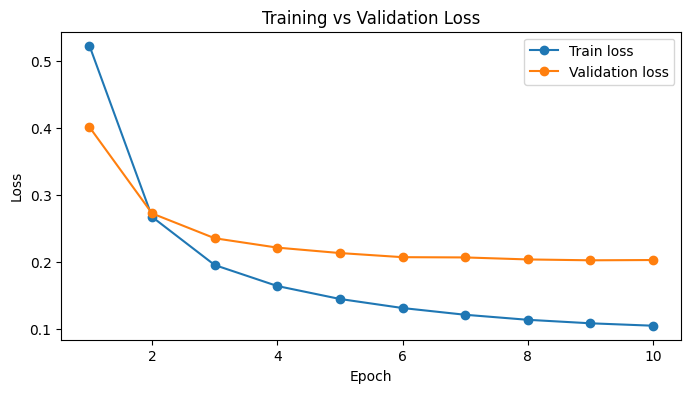

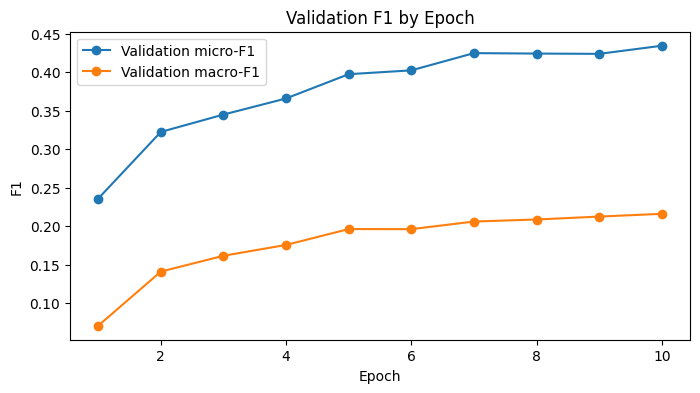

In [15]:
import matplotlib.pyplot as plt
import pandas as pd # Import pandas

# Convert history list of dicts to a DataFrame for easier plotting
history_df = pd.DataFrame(history)

plt.figure(figsize=(8, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history_df["epoch"], history_df["val_micro_f1"], marker="o", label="Validation micro-F1")
plt.plot(history_df["epoch"], history_df["val_macro_f1"], marker="o", label="Validation macro-F1")
plt.xlabel("Epoch")
plt.ylabel("F1")
plt.title("Validation F1 by Epoch")
plt.legend()
plt.show()

In [16]:
transformer_metrics, test_probabilities, transformer_pred, test_labels = evaluate_model(
    model,
    test_loader,
    threshold=THRESHOLD
)

print("Transformer test metrics:")
display(pd.Series(transformer_metrics).round(4))


Evaluating:   0%|          | 0/313 [00:00<?, ?it/s]

Transformer test metrics:


,0
micro_f1,0.3887
macro_f1,0.1978
micro_precision,0.2543
macro_precision,0.1463
micro_recall,0.8248
macro_recall,0.4773
exact_match,0.0000
loss,0.2545


In [17]:
import numpy as np # Ensure numpy is available for np.nan

comparison = pd.DataFrame([
    {
        "Model": "TF-IDF + Logistic Regression",
        "Micro-F1": baseline_metrics.get("micro_f1", np.nan),
        "Macro-F1": baseline_metrics.get("macro_f1", np.nan),
        "Micro-Precision": baseline_metrics.get("micro_precision", np.nan),
        "Micro-Recall": baseline_metrics.get("micro_recall", np.nan),
        "Exact-Match": baseline_metrics.get("exact_match", np.nan),
        "Training time (sec)": baseline_metrics.get("baseline_train_time", np.nan)
    },
    {
        "Model": MODEL_NAME,
        "Micro-F1": transformer_metrics["micro_f1"],
        "Macro-F1": transformer_metrics["macro_f1"],
        "Micro-Precision": transformer_metrics["micro_precision"],
        "Micro-Recall": transformer_metrics["micro_recall"],
        "Exact-Match": transformer_metrics["exact_match"],
        "Training time (sec)": total_training_time
    }
])

display(comparison.round(4))


,Model,Micro-F1,Macro-F1,Micro-Precision,Micro-Recall,Exact-Match,Training time (sec)
0,TF-IDF + Logistic Regression,NaN,NaN,NaN,NaN,NaN,NaN
1,xlm-roberta-base,0.3887,0.1978,0.2543,0.8248,0.0,1266.4094


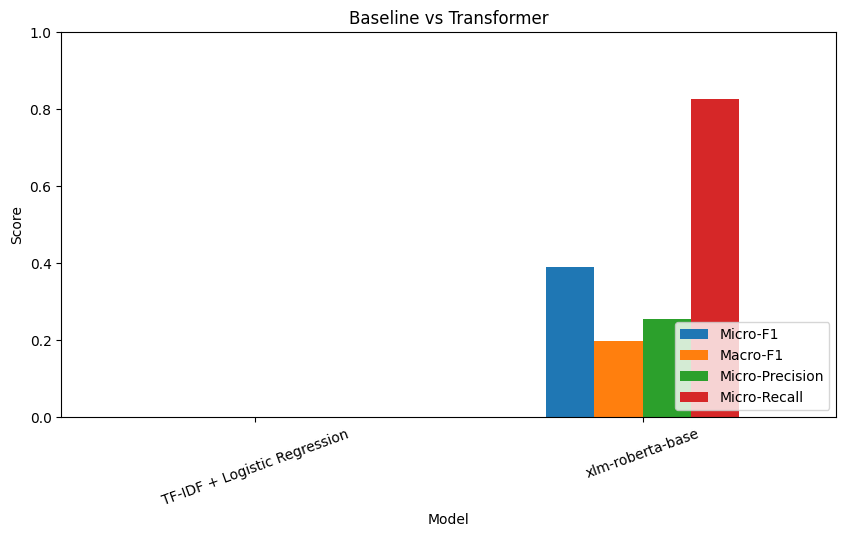

In [18]:
metric_cols = ["Micro-F1", "Macro-F1", "Micro-Precision", "Micro-Recall"]

comparison.set_index("Model")[metric_cols].plot(
    kind="bar",
    figsize=(10, 5),
    ylim=(0, 1)
)

plt.ylabel("Score")
plt.title("Baseline vs Transformer")
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.show()


In [19]:
threshold_results = []

for threshold in [0.05, 0.30, 0.40, 0.50, 0.60, 0.70]:
    pred = (test_probabilities >= threshold).astype(int)

    m = multilabel_metrics(test_labels, pred)

    threshold_results.append({
        "threshold": threshold,
        "micro_f1": m["micro_f1"],
        "macro_f1": m["macro_f1"],
        "micro_precision": m["micro_precision"],
        "micro_recall": m["micro_recall"]
    })

threshold_df = pd.DataFrame(threshold_results)
display(threshold_df.round(4))


,threshold,micro_f1,macro_f1,micro_precision,micro_recall
0,0.05,0.1000,0.0579,0.0527,0.9582
1,0.30,0.2752,0.1474,0.1630,0.8813
2,0.40,0.3326,0.1733,0.2065,0.8548
3,0.50,0.3887,0.1978,0.2543,0.8248
4,0.60,0.4453,0.2232,0.3100,0.7898
5,0.70,0.5021,0.2447,0.3788,0.7445


In [20]:
thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

results = []

for threshold in thresholds:
    metrics, _, _, _ = evaluate_model(
        model,
        test_loader,
        threshold=threshold
    )

    results.append({
        "threshold": threshold,
        **metrics
    })

threshold_results = pd.DataFrame(results)

display(threshold_results.round(4))

Evaluating:   0%|          | 0/313 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/313 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/313 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/313 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/313 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/313 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/313 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/313 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/313 [00:00<?, ?it/s]

,threshold,micro_f1,macro_f1,micro_precision,macro_precision,micro_recall,macro_recall,exact_match,loss
0,0.05,0.1000,0.0579,0.0527,0.0327,0.9582,0.7174,0.0,0.2545
1,0.10,0.1445,0.0820,0.0783,0.0482,0.9382,0.6687,0.0,0.2545
2,0.15,0.1812,0.1019,0.1005,0.0621,0.9213,0.6389,0.0,0.2545
3,0.20,0.2144,0.1183,0.1216,0.0752,0.9073,0.6129,0.0,0.2545
4,0.25,0.2451,0.1318,0.1420,0.0842,0.8941,0.5894,0.0,0.2545
5,0.30,0.2752,0.1474,0.1630,0.0968,0.8813,0.5653,0.0,0.2545
6,0.35,0.3043,0.1611,0.1845,0.1099,0.8680,0.5408,0.0,0.2545
7,0.40,0.3326,0.1733,0.2065,0.1225,0.8548,0.5155,0.0,0.2545
8,0.45,0.3603,0.1843,0.2294,0.1339,0.8395,0.4942,0.0,0.2545
9,0.50,0.3887,0.1978,0.2543,0.1463,0.8248,0.4773,0.0,0.2545


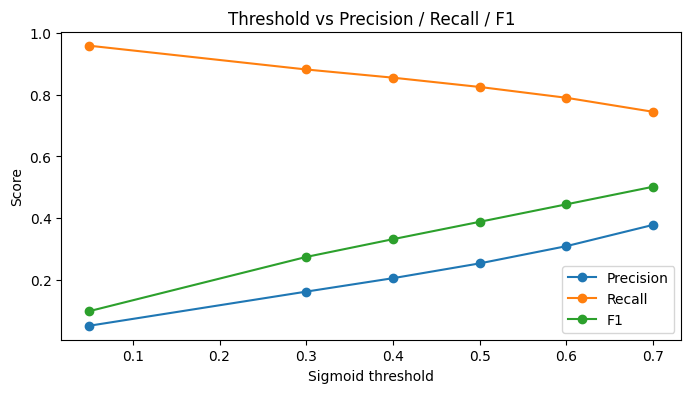

In [21]:
plt.figure(figsize=(8, 4))
plt.plot(threshold_df["threshold"], threshold_df["micro_precision"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["micro_recall"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["micro_f1"], marker="o", label="F1")
plt.xlabel("Sigmoid threshold")
plt.ylabel("Score")
plt.title("Threshold vs Precision / Recall / F1")
plt.legend()
plt.show()


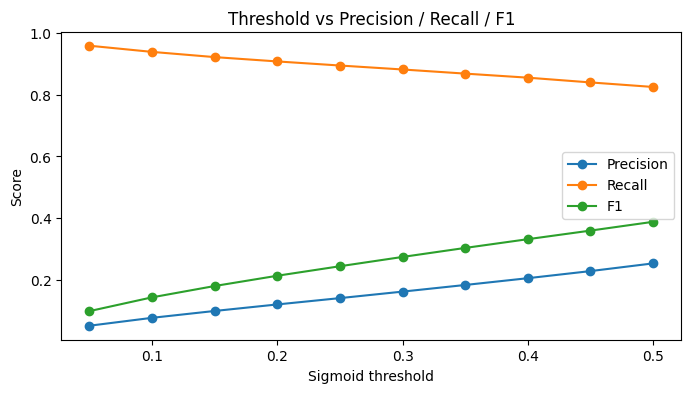

In [22]:
threshold_df = threshold_results  # alias, so the plotting code works as-is
plt.figure(figsize=(8, 4))
plt.plot(threshold_df["threshold"], threshold_df["micro_precision"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["micro_recall"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["micro_f1"], marker="o", label="F1")
plt.xlabel("Sigmoid threshold")
plt.ylabel("Score")
plt.title("Threshold vs Precision / Recall / F1")
plt.legend()
plt.show()



Languages:   0%|          | 0/23 [00:00<?, ?it/s]

  bg:   0%|          | 0/313 [00:00<?, ?it/s]

  bg: n=5000 done.


  cs:   0%|          | 0/313 [00:00<?, ?it/s]

  cs: n=5000 done.


...

,0
micro_precision,0.1681
micro_recall,0.7359
micro_f1,0.2737
macro_precision,0.1092
macro_recall,0.3992
macro_f1,0.1411
exact_match,0.0000



=== Overall metrics — AVERAGED across the 23 per-language scores (threshold = 0.5) ===


,0
micro_precision,0.1693
micro_recall,0.7359
micro_f1,0.2741
macro_precision,0.1074
macro_recall,0.3992
macro_f1,0.1423



=== Threshold sweep (pooled across all 23 languages) ===


,threshold,micro_precision,micro_recall,micro_f1,macro_f1
0,0.05,0.0381,0.9523,0.0733,0.0451
1,0.10,0.0547,0.9206,0.1033,0.0623
2,0.15,0.0689,0.8927,0.1279,0.0756
3,0.20,0.0822,0.8673,0.1502,0.0868
4,0.25,0.0953,0.8446,0.1713,0.0970
5,0.30,0.1086,0.8233,0.1919,0.1067
6,0.35,0.1223,0.8017,0.2123,0.1161
7,0.40,0.1366,0.7800,0.2325,0.1247
8,0.45,0.1518,0.7583,0.2529,0.1331
9,0.50,0.1681,0.7359,0.2737,0.1411


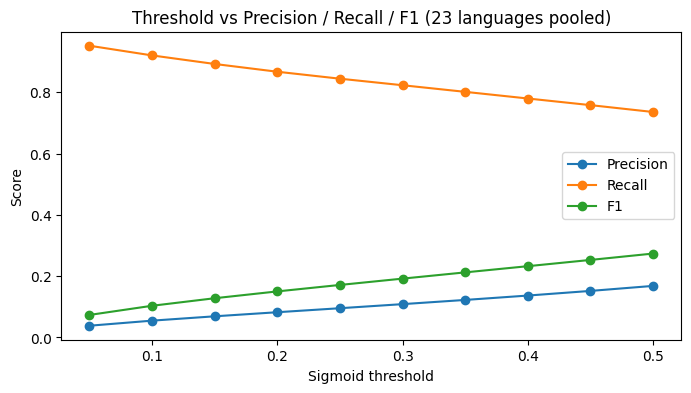

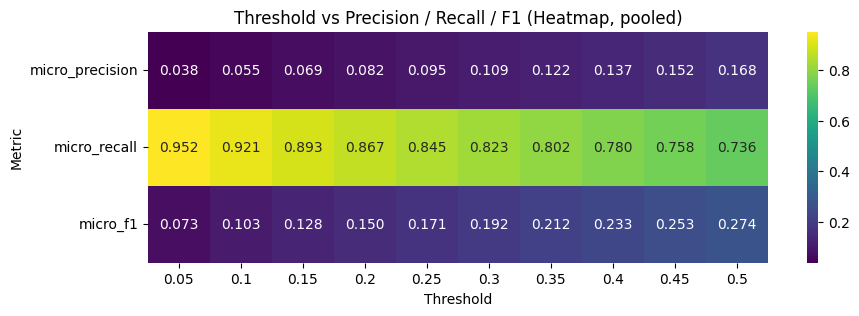

In [23]:
from tqdm.auto import tqdm
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import numpy as np
import torch
import pandas as pd
import seaborn as sns


LANGUAGES = ['bg', 'cs', 'da', 'de', 'el', 'en', 'es', 'et', 'fi', 'fr', 'hr',
             'hu', 'it', 'lt', 'lv', 'mt', 'nl', 'pl', 'pt', 'ro', 'sk', 'sl', 'sv']

# ============================================================
# STEP 1 — Run inference ONCE across all 23 languages
# Produces raw probabilities + true labels per language.
# Everything else below is derived from this without re-running the model.
# ============================================================

def evaluate_multilingual_full(model, tokenizer, raw_dataset, label_to_index,
                                 num_labels, languages, batch_size=16, max_length=256):
    model.eval()
    probs_by_lang, true_by_lang = {}, {}

    for lang in tqdm(languages, desc="Languages"):
        texts, label_rows = [], []
        for row in raw_dataset:
            text = row["text"].get(lang)
            if text:
                texts.append(text)
                mh = np.zeros(num_labels, dtype=np.float32)
                for l in row["labels"]:
                    if l in label_to_index:
                        mh[label_to_index[l]] = 1.0
                label_rows.append(mh)
        if not texts:
            tqdm.write(f"  Skipping {lang}: no documents found.")
            continue

        logits_list = []
        n_batches = (len(texts) + batch_size - 1) // batch_size
        for i in tqdm(range(0, len(texts), batch_size), total=n_batches, desc=f"  {lang}", leave=False):
            enc = tokenizer(texts[i:i+batch_size], truncation=True, padding=True,
                             max_length=max_length, return_tensors="pt").to(accelerator.device)
            with torch.no_grad():
                out = model(**enc)
            logits_list.append(out.logits.cpu())

        probs_by_lang[lang] = torch.sigmoid(torch.cat(logits_list)).numpy()
        true_by_lang[lang] = np.stack(label_rows)
        tqdm.write(f"  {lang}: n={len(texts)} done.")

    return probs_by_lang, true_by_lang


# Run it (replace `model`, `tokenizer`, `dataset["test"]`, `label_to_index`, `NUM_LABELS`
# with your actual variables)
probs_by_lang, true_by_lang = evaluate_multilingual_full(
    accelerator.unwrap_model(model), tokenizer, dataset["test"],
    label_to_index, NUM_LABELS, LANGUAGES
)

# Save immediately so you never lose this even if the model/session is gone later
np.savez(
    "/content/drive/MyDrive/eval_probs_mbert_weight.npz",
    **{f"{l}_probs": probs_by_lang[l] for l in probs_by_lang},
    **{f"{l}_true": true_by_lang[l] for l in true_by_lang}
)
print("Saved raw probabilities + labels to Drive.\n")


# ============================================================
# STEP 2 — Per-language metrics (fixed threshold = 0.5)
# ============================================================

def build_per_lang_df(probs_by_lang, true_by_lang, threshold=0.5):
    results = []
    for lang, probs in probs_by_lang.items():
        preds = (probs >= threshold).astype(int)
        y_true = true_by_lang[lang]
        results.append({
            "language": lang,
            "n_examples": len(probs),
            "micro_precision": precision_score(y_true, preds, average="micro", zero_division=0),
            "micro_recall": recall_score(y_true, preds, average="micro", zero_division=0),
            "micro_f1": f1_score(y_true, preds, average="micro", zero_division=0),
            "macro_precision": precision_score(y_true, preds, average="macro", zero_division=0),
            "macro_recall": recall_score(y_true, preds, average="macro", zero_division=0),
            "macro_f1": f1_score(y_true, preds, average="macro", zero_division=0),
        })
    return pd.DataFrame(results)

per_lang_df = build_per_lang_df(probs_by_lang, true_by_lang, threshold=0.5)
print("=== Per-language metrics (threshold = 0.5) ===")
display(per_lang_df.round(4))


# ============================================================
# STEP 3 — Overall metrics: POOLED and AVERAGED
# ============================================================

pooled_probs = np.concatenate(list(probs_by_lang.values()))
pooled_true = np.concatenate(list(true_by_lang.values()))
pooled_preds = (pooled_probs >= 0.5).astype(int)

pooled_overall = {
    "micro_precision": precision_score(pooled_true, pooled_preds, average="micro", zero_division=0),
    "micro_recall": recall_score(pooled_true, pooled_preds, average="micro", zero_division=0),
    "micro_f1": f1_score(pooled_true, pooled_preds, average="micro", zero_division=0),
    "macro_precision": precision_score(pooled_true, pooled_preds, average="macro", zero_division=0),
    "macro_recall": recall_score(pooled_true, pooled_preds, average="macro", zero_division=0),
    "macro_f1": f1_score(pooled_true, pooled_preds, average="macro", zero_division=0),
    "exact_match": accuracy_score(pooled_true, pooled_preds),
}

print("\n=== Overall metrics — POOLED across all 23 languages (threshold = 0.5) ===")
display(pd.Series(pooled_overall).round(4))

overall_avg = per_lang_df[[
    "micro_precision", "micro_recall", "micro_f1",
    "macro_precision", "macro_recall", "macro_f1"
]].mean()

print("\n=== Overall metrics — AVERAGED across the 23 per-language scores (threshold = 0.5) ===")
display(overall_avg.round(4))


# ============================================================
# STEP 4 — Threshold sweep (pooled across all 23 languages)
# ============================================================

thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
threshold_results = []

for t in thresholds:
    preds = (pooled_probs >= t).astype(int)
    threshold_results.append({
        "threshold": t,
        "micro_precision": precision_score(pooled_true, preds, average="micro", zero_division=0),
        "micro_recall": recall_score(pooled_true, preds, average="micro", zero_division=0),
        "micro_f1": f1_score(pooled_true, preds, average="micro", zero_division=0),
        "macro_f1": f1_score(pooled_true, preds, average="macro", zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_results)
print("\n=== Threshold sweep (pooled across all 23 languages) ===")
display(threshold_df.round(4))

# --- Plots ---
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
plt.plot(threshold_df["threshold"], threshold_df["micro_precision"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["micro_recall"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["micro_f1"], marker="o", label="F1")
plt.xlabel("Sigmoid threshold")
plt.ylabel("Score")
plt.title("Threshold vs Precision / Recall / F1 (23 languages pooled)")
plt.legend()
plt.show()

heatmap_data = threshold_df.set_index("threshold")[["micro_precision", "micro_recall", "micro_f1"]].T
plt.figure(figsize=(10, 3))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="viridis")
plt.xlabel("Threshold")
plt.ylabel("Metric")
plt.title("Threshold vs Precision / Recall / F1 (Heatmap, pooled)")
plt.show()

In [1]:
# Parameter count
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

if torch.cuda.is_available():
    print(f"Peak GPU memory: {torch.cuda.max_memory_allocated()/1024**3:.2f} GB")


NameError: name 'model' is not defined

In [25]:
# Measure inference time on the test loader
model.eval()

if torch.cuda.is_available():
    torch.cuda.synchronize()

start = time.perf_counter()

# Use the prepared test_loader for inference
for batch in test_loader:
    # accelerator handles placing batch on device
    with torch.no_grad():
        _ = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"]
        )

if torch.cuda.is_available():
    torch.cuda.synchronize()

inference_time = time.perf_counter() - start

print(f"Test inference time: {inference_time:.2f} sec")
print(f"Documents/sec: {len(tokenized_dataset['test'])/inference_time:.2f}")

Test inference time: 7.62 sec
Documents/sec: 656.03


In [26]:
cost_comparison = pd.DataFrame([
    {
        "Model": "TF-IDF + Logistic Regression",
        "Macro-F1": baseline_metrics.get("macro_f1", np.nan),
        "Micro-F1": baseline_metrics.get("micro_f1", np.nan),
        "Training time (sec)": baseline_metrics.get("baseline_train_time", np.nan),
        "Inference time (sec)": np.nan,
        "Parameters": np.nan
    },
    {
        "Model": MODEL_NAME,
        "Macro-F1": transformer_metrics["macro_f1"],
        "Micro-F1": transformer_metrics["micro_f1"],
        "Training time (sec)": total_training_time,
        "Inference time (sec)": inference_time,
        "Parameters": total_params
    }
])

display(cost_comparison.round(4))

,Model,Macro-F1,Micro-F1,Training time (sec),Inference time (sec),Parameters
0,TF-IDF + Logistic Regression,NaN,NaN,NaN,NaN,NaN
1,xlm-roberta-base,0.1978,0.3887,1266.4094,7.6216,278479671.0


In [27]:
### Label-wise F1 Analysis (Transformer Only)

transformer_label_f1 = f1_score(
    test_labels, transformer_pred, average=None, zero_division=0
)

# Create a DataFrame for label-wise transformer F1 scores
label_analysis_df = pd.DataFrame({
    "label_index": range(NUM_LABELS),
    "transformer_f1": transformer_label_f1,
    "support": test_labels.sum(axis=0).astype(int) # Using test_labels for support
})

print("Top 15 Transformer F1 Scores by Label:")
display(
    label_analysis_df.sort_values("transformer_f1", ascending=False).head(15)
)

print("Bottom 15 Transformer F1 Scores by Label:")
display(
    label_analysis_df.sort_values("transformer_f1").head(15)
)

# The previous cell previously compared label-wise F1 scores between the baseline and transformer models.
# Since the baseline model is no longer being trained and its predictions are unavailable,
# the comparison aspect has been removed, and this cell now focuses on the transformer's performance.

Top 15 Transformer F1 Scores by Label:


,label_index,transformer_f1,support
78,78,0.973251,481
55,55,0.888889,4
519,519,0.847059,1228
505,505,0.840187,1016
528,528,0.832755,664
419,419,0.821767,543
423,423,0.818612,543
522,522,0.814221,893
179,179,0.809672,627
197,197,0.807742,315


Bottom 15 Transformer F1 Scores by Label:


,label_index,transformer_f1,support
558,558,0.0,2
555,555,0.0,5
2,2,0.0,0
397,397,0.0,0
46,46,0.0,0
401,401,0.0,0
56,56,0.0,0
54,54,0.0,0
385,385,0.0,0
381,381,0.0,0


In [28]:
print(dataset["test"].column_names)
print(dataset["test"][0])

['celex_id', 'text', 'labels']
{'celex_id': '32013R1390', 'text': {'bg': 'РЕГЛАМЕНТ (ЕС) № 1390/2013 НА СЪВЕТА\nот 16 декември 2013 година\nотносно разпределянето на възможностите за риболов съгласно протокола между Европейския съюз и Съюза на Коморските острови за определяне на възможностите за риболов и на финансовото участие, предвидени в действащото Споразумение за партньорство в областта на рибарството между двете страни\nСЪВЕТЪТ НА ЕВРОПЕЙСКИЯ СЪЮЗ,\nкато взе предвид Договора за функционирането на Европейския съюз, и по-специално член 43, параграф 3 от него,\nкато взе предвид предложението на Европейската комисия,\nкато има предвид, че:\n(1)\nНа 5 октомври 2006 г. Съветът одобри Споразумението за партньорство в областта на рибарството между Европейската общност и Съюза на Коморските острови (по-нататък наричано „Споразумение за партньорство“) с приемането на Регламент (ЕО) №1563/2006 (1).\n(2)\nЕвропейският съюз договори със Съюза на Коморските острови нов протокол към споразумен

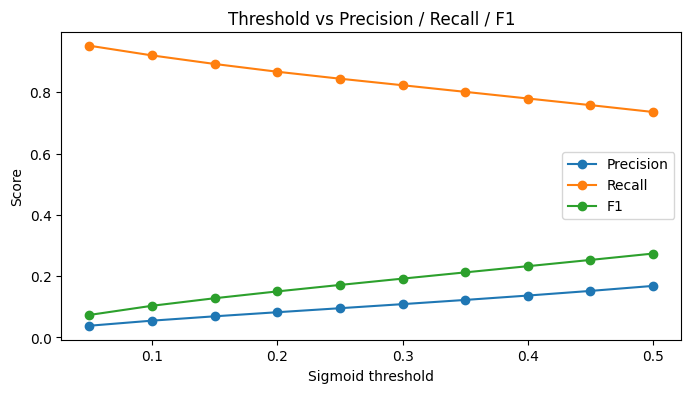

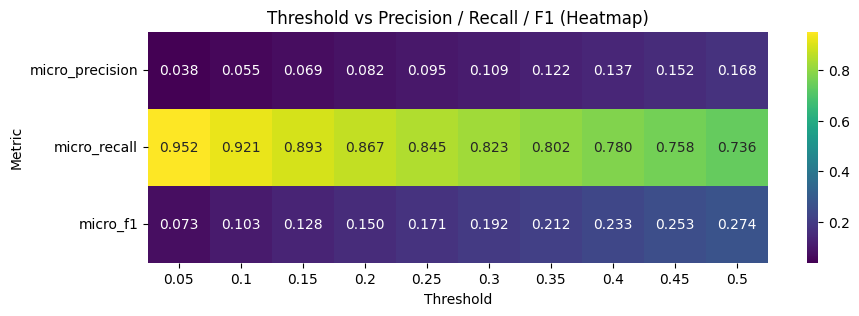

In [29]:
import seaborn as sns
# --- Line plot ---
plt.figure(figsize=(8, 4))
plt.plot(threshold_df["threshold"], threshold_df["micro_precision"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["micro_recall"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["micro_f1"], marker="o", label="F1")
plt.xlabel("Sigmoid threshold")
plt.ylabel("Score")
plt.title("Threshold vs Precision / Recall / F1")
plt.legend()
plt.show()

# --- Heatmap ---
heatmap_data = threshold_df.set_index("threshold")[["micro_precision", "micro_recall", "micro_f1"]].T

plt.figure(figsize=(10, 3))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="viridis")
plt.xlabel("Threshold")
plt.ylabel("Metric")
plt.title("Threshold vs Precision / Recall / F1 (Heatmap)")
plt.show()

In [30]:
import os

output_path = "/content/drive/MyDrive/xlm-rob_weighted.csv"
per_lang_df.to_csv(output_path, index=False)
print(f"Saved to {output_path}")

Saved to /content/drive/MyDrive/xlm-rob_weighted.csv


In [31]:
### Label-wise F1 Analysis (Transformer Only)

from sklearn.metrics import precision_score, recall_score, f1_score

transformer_label_f1 = f1_score(
    test_labels, transformer_pred, average=None, zero_division=0
)
transformer_label_precision = precision_score(
    test_labels, transformer_pred, average=None, zero_division=0
)
transformer_label_recall = recall_score(
    test_labels, transformer_pred, average=None, zero_division=0
)

# Create a DataFrame for label-wise transformer scores, including rarity (support)
label_analysis_df = pd.DataFrame({
    "label_index": range(NUM_LABELS),
    "transformer_precision": transformer_label_precision,
    "transformer_recall": transformer_label_recall,
    "transformer_f1": transformer_label_f1,
    "support": test_labels.sum(axis=0).astype(int)  # rarity: how many times this label appears in test set
})

# Sort by rarity (rarest labels first) — makes the imbalance story easy to read top-to-bottom
label_analysis_df = label_analysis_df.sort_values("support").reset_index(drop=True)

print(f"Label-wise F1 analysis for all {NUM_LABELS} labels (sorted by rarity, rarest first):")
display(label_analysis_df.round(4))

# Save full table to Drive
output_path = "/content/drive/MyDrive/label_wise_f1_xlm-r_weighted.csv"
label_analysis_df.to_csv(output_path, index=False)
print(f"\nSaved to {output_path}")


Label-wise F1 analysis for all 567 labels (sorted by rarity, rarest first):


,label_index,transformer_precision,transformer_recall,transformer_f1,support
0,20,0.0000,0.0000,0.0000,0
1,2,0.0000,0.0000,0.0000,0
2,341,0.0000,0.0000,0.0000,0
3,343,0.0000,0.0000,0.0000,0
4,340,0.0000,0.0000,0.0000,0
...,...,...,...,...,...
562,505,0.7998,0.8848,0.8402,1016
563,126,0.6849,0.9332,0.7900,1018
564,479,0.7281,0.8658,0.7910,1036
565,115,0.8175,0.4972,0.6184,1090



Saved to /content/drive/MyDrive/label_wise_f1_xlm-r_weighted.csv


In [ ]:
import time
import os

print("Training completed. Terminating runtime in 10 seconds...")
time.sleep(10)
os.kill(os.getpid(), 9)

Training completed. Terminating runtime in 10 seconds...
